# Visualize Selected Populations for Marker Based Optimization.

## Prepare Notebook.

### Autoreload Libraries.

In [ ]:
%reload_ext autoreload
%autoreload 2

### Import Libraries.

In [1]:
from functools import partial
import sys

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch


import hydra
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import torch

import labcompass

sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/shared_utils")

from experiment_utils import get_forward_model, generate_with_condition, generated_density_knn, get_adata_from_idx
from data_utils import (
    standardize_array_and_write_to_adata, get_condition_data_from_file,
    get_protocol_tranformations, get_target_adata_marker_opt
)
from inverse_utils import (
    map_df, l2_loss, l1_loss, hinge_loss, cauchy_loss, loss_fn_factory_marker_opt,
    linear_scheduler_with_warmup, constraint_fn_factory
)
from lambda_schedulers import ReciprocalDecayScheduler
from plot_utils import plot_all_markers_overlay


## Load Stuff.

### Configurations.

In [3]:
with hydra.initialize(
    config_path="../../../config"
):
    config = hydra.compose(
        config_name="run_inverse_constrained",
        overrides=[
            "paths=bloodplus_fm",
            "annotation=bloodplus",
            "sampling.N=10",
            "sampling.num_time_steps=20",
            "forward_model.num_time_steps=20",
            "constraints=default_all_cols"
        ]
    )

/tmp/ipykernel_4149545/2220545396.py:1: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with hydra.initialize(


### Load Models.

In [4]:
forward_model, (
    phi_model,
    target_prediction_model
) = get_forward_model(config)
forward_model.target_prediction_model.resc_model["model"].eval()
forward_model.forward_model.velocity_field.eval()
print(forward_model.target_prediction_model.resc_model["model"])
print(forward_model.forward_model.velocity_field)

PerturbationApproximatePosterior(
  (pert_approximate_posterior): ModuleDict(
    (encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=256, bias=True)
          (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout(p=0.1, inplace=False)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout(p=0.1, inplace=False)
        )
        (2): Sequential(
          (0): Linear(in_features=256, out_features=32, bias=True)
          (1): Identity()
        )
      )
    )
    (cell_type): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=32, out_features=24, bias=True)
          (1): Identity()
        )
      )
    )
  )
)


### Concatenate Annotated Data.

In [6]:
train_adata_phi = phi_model.train_data.adata
train_adata_g = target_prediction_model.train_data.adata
val_adata_g = target_prediction_model.validation_data.adata
adata_g = sc.concat((train_adata_g, val_adata_g), uns_merge="same")

## CD41a.

Number query cells before aggregation: 2360
Number query cells after aggregation: 1


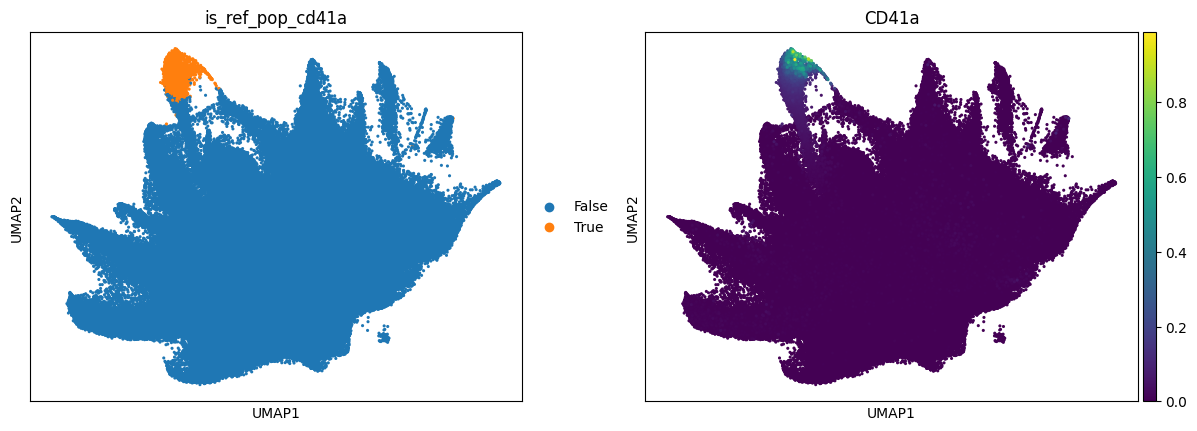

In [15]:
target_marker_names = ["CD41a"]
target_morph_feat_names = []

target_quantile = 99.5
agg_fn = np.min
filter_dict = {}
target_adata_cd41a, query_adata_cd41a = get_target_adata_marker_opt(
    train_adata_phi,
    adata_g,
    agg_fn,
    target_marker_names,
    config.loss.target_morph_feat_names,
    config.annotation.scatter_columns,
    filter_dict,
    target_quantile,
    agg_fn_kwargs=config.loss.agg_fn_kwargs,
)

# visualize
ref_main_idx = adata_g.obs.index.map(lambda e: e in query_adata_cd41a.obs.index)
adata_g.obs["is_ref_pop_cd41a"] = ref_main_idx
target_feat_names = target_marker_names + target_morph_feat_names
sc.pl.embedding(adata_g, "umap", color=["is_ref_pop_cd41a"] + target_feat_names, s=20)

## CD56.

Number query cells before aggregation: 2360
Number query cells after aggregation: 1


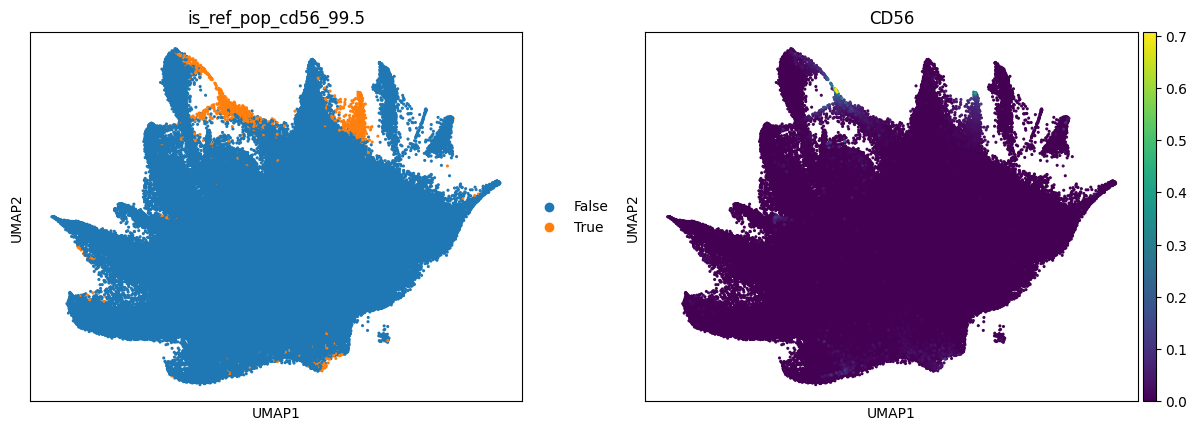

Number query cells before aggregation: 1180
Number query cells after aggregation: 1


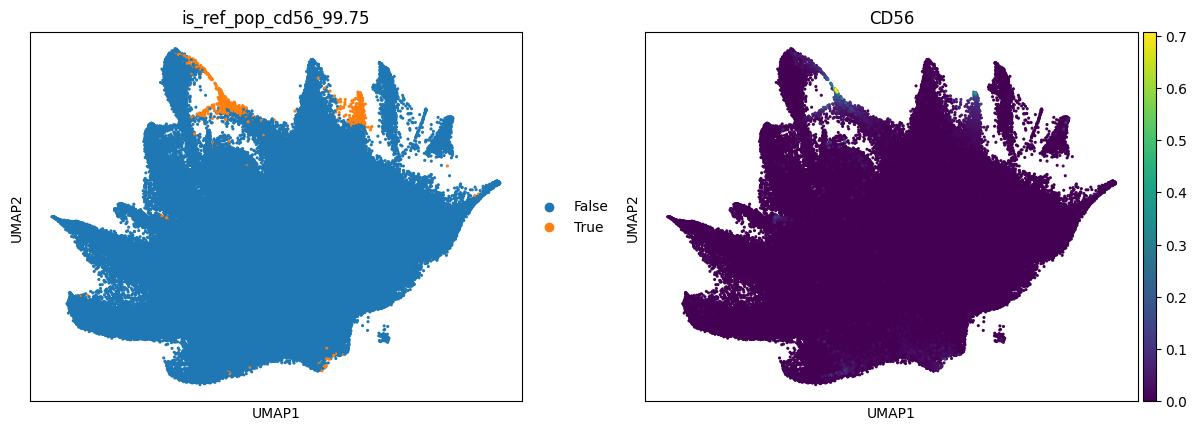

Number query cells before aggregation: 472
Number query cells after aggregation: 1


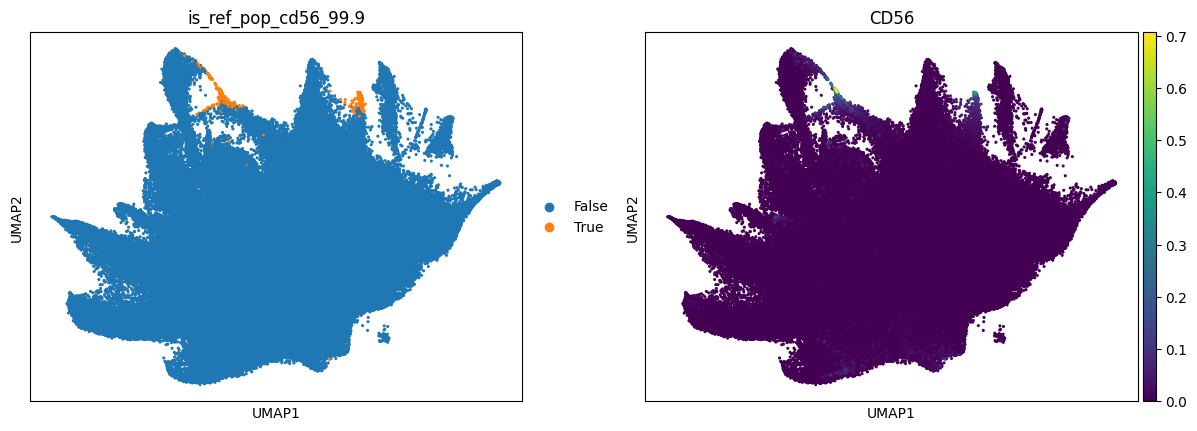

In [25]:
target_marker_names = ["CD56"]
target_morph_feat_names = []
target_quantile = 99.5
agg_fn = np.min
filter_dict = {}
for target_quantile in [99.5, 99.75, 99.9]:
    target_adata_cd56, query_adata_cd56 = get_target_adata_marker_opt(
        train_adata_phi,
        adata_g,
        agg_fn,
        target_marker_names,
        config.loss.target_morph_feat_names,
        config.annotation.scatter_columns,
        filter_dict,
        target_quantile,
        agg_fn_kwargs=config.loss.agg_fn_kwargs,
    )

    # visualize
    ref_main_idx = adata_g.obs.index.map(lambda e: e in query_adata_cd56.obs.index)
    adata_g.obs[f"is_ref_pop_cd56_{target_quantile}"] = ref_main_idx
    target_feat_names = target_marker_names + target_morph_feat_names
    sc.pl.embedding(adata_g, "umap", color=[f"is_ref_pop_cd56_{target_quantile}"] + target_feat_names, s=20)

## EPCR.

Number query cells before aggregation: 2360
Number query cells after aggregation: 1


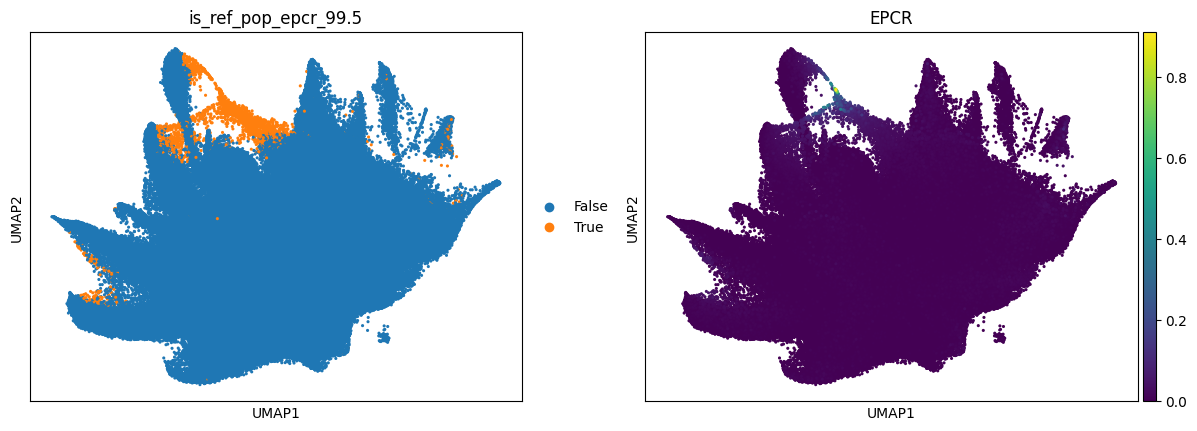

Number query cells before aggregation: 1180
Number query cells after aggregation: 1


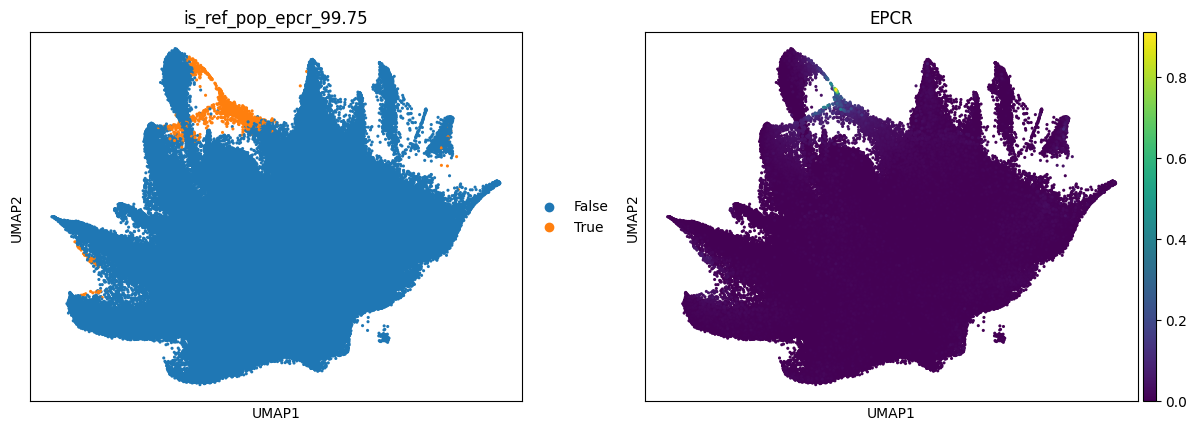

Number query cells before aggregation: 472
Number query cells after aggregation: 1


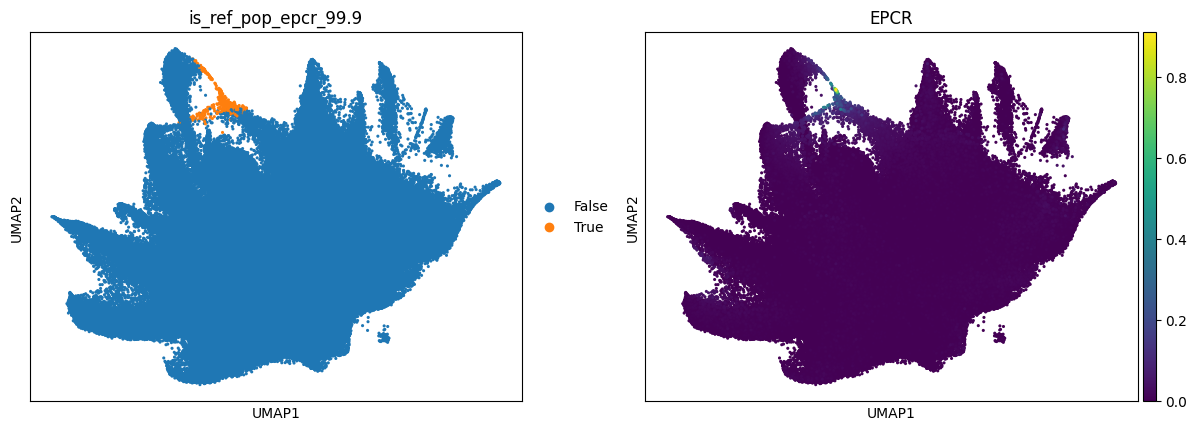

In [26]:
target_marker_names = ["EPCR"]
target_morph_feat_names = []
target_quantile = 99.5
agg_fn = np.min
filter_dict = {}
for target_quantile in [99.5, 99.75, 99.9]:
    target_adata_epcr, query_adata_epcr = get_target_adata_marker_opt(
        train_adata_phi,
        adata_g,
        agg_fn,
        target_marker_names,
        config.loss.target_morph_feat_names,
        config.annotation.scatter_columns,
        filter_dict,
        target_quantile,
        agg_fn_kwargs=config.loss.agg_fn_kwargs,
    )

    # visualize
    ref_main_idx = adata_g.obs.index.map(lambda e: e in query_adata_epcr.obs.index)
    adata_g.obs[f"is_ref_pop_epcr_{target_quantile}"] = ref_main_idx
    target_feat_names = target_marker_names + target_morph_feat_names
    sc.pl.embedding(adata_g, "umap", color=[f"is_ref_pop_epcr_{target_quantile}"] + target_feat_names, s=20)